In [139]:
import sys
sys.path.append('..')

import yfinance as yf
import pandas as pd
from datetime import date, datetime
from src.black_scholes import implied_volatility
import matplotlib.pyplot as plt
%matplotlib widget
from matplotlib import cm
import numpy as np
from scipy.interpolate import griddata

In [140]:
ticker_symbol = 'SPY'
ticker = yf.Ticker(ticker_symbol)
S = ticker.history()['Close'].iloc[-1]
print(S)

648.5700073242188


In [141]:
call_prices = []
call_strikes = []
call_maturities = []
#call_volumes = []

put_prices = []
put_strikes = []
put_maturities = []
#put_volumes = []

for maturity in ticker.options:
    chain = ticker.option_chain(maturity)
    for _ in range(len(chain.calls)):
        call_maturities.append(maturity)
        call_prices.append((chain.calls['bid'][_] + chain.calls['ask'][_]) / 2)
        call_strikes.append(chain.calls['strike'][_])
        #call_volumes.append(chain.calls['volume'][_])
    for _ in range(len(chain.puts)):
        put_maturities.append(maturity)
        put_prices.append((chain.puts['bid'][_] + chain.puts['ask'][_]) / 2)
        put_strikes.append(chain.puts['strike'][_])
        #put_volumes.append(chain.puts['volume'][_])

#calls = pd.DataFrame({'price': call_prices, 'strike': call_strikes, 'maturityDate': call_maturities, 'volume': call_volumes})
#puts = pd.DataFrame({'price': put_prices, 'strike': put_strikes, 'maturityDate': put_maturities, 'volume': put_volumes})

calls = pd.DataFrame({'price': call_prices, 'strike': call_strikes, 'maturityDate': call_maturities})
puts = pd.DataFrame({'price': put_prices, 'strike': put_strikes, 'maturityDate': put_maturities})

In [142]:
calls['maturityDate'] = pd.to_datetime(calls['maturityDate'])
puts['maturityDate'] = pd.to_datetime(puts['maturityDate'])

In [143]:
call_maturities = []
put_maturities = []
for _ in range(len(calls['maturityDate'])):
    diff = calls['maturityDate'][_].to_pydatetime() - datetime.today()
    call_maturities.append(diff.days/252)
for _ in range(len(puts['maturityDate'])):
    diff = puts['maturityDate'][_].to_pydatetime() - datetime.today()
    put_maturities.append(diff.days/252)

calls['maturity'] = call_maturities
puts['maturity'] = put_maturities

In [144]:
calls = calls[calls['maturity'] >= 7/252].reset_index(drop=True)
puts = puts[puts['maturity'] >= 7/252].reset_index(drop=True)

calls = calls[calls['price'] > 0].reset_index(drop=True)
puts = puts[puts['price'] > 0].reset_index(drop=True)

calls = calls[(calls['strike'] >= 0.2 * S) & (calls['strike'] <= 1.8 * S)].reset_index(drop=True)
puts = puts[(puts['strike'] >= 0.2 * S) & (puts['strike'] <= 1.2 * S)].reset_index(drop=True)

#calls = calls[calls['volume'] > 10].reset_index(drop=True)
#puts = puts[puts['volume'] > 10].reset_index(drop=True)

In [145]:
calls_implied_vol = []
for _, row in calls.iterrows():
    try:
        implied_vol = implied_volatility(
            row['price'],
            S, 
            row['strike'], 
            row['maturity'], 
            r=0.05, 
            method='bisection'     
        )
        calls_implied_vol.append(implied_vol)
    except:
        calls_implied_vol.append(None)

calls['implied_vol'] = calls_implied_vol
print(f'{calls['implied_vol'].isna().sum()} calls without implied volatility')
print(calls.head())

19 calls without implied volatility
     price  strike maturityDate  maturity  implied_vol
0  321.900   355.0   2026-03-31  0.027778     3.855663
1  283.795   370.0   2026-03-31  0.027778     2.190875
2  298.345   395.0   2026-03-31  0.027778     4.044924
3  252.860   425.0   2026-03-31  0.027778     3.012406
4  258.725   435.0   2026-03-31  0.027778     3.515082


In [146]:
puts_implied_vol = []
for _, row in puts.iterrows():
    try:
        implied_vol = implied_volatility(
            row['price'],
            S,
            row['strike'],
            row['maturity'],
            r=0.05,
            option_type='put',
            method='bisection'
        )
        puts_implied_vol.append(implied_vol)
    except:
        puts_implied_vol.append(None)

puts['implied_vol'] = puts_implied_vol
print(f'{puts['implied_vol'].isna().sum()} puts without implied volatility')
print(puts.head())

35 puts without implied volatility
    price  strike maturityDate  maturity  implied_vol
0  39.615   716.0   2026-03-31  0.027778          NaN
1  40.600   717.0   2026-03-31  0.027778          NaN
2  44.545   721.0   2026-03-31  0.027778          NaN
3  47.530   724.0   2026-03-31  0.027778          NaN
4  51.510   728.0   2026-03-31  0.027778          NaN


In [147]:
calls = calls[(calls['implied_vol'] > 0.01) & (calls['implied_vol'] < 1)].reset_index(drop=True)
puts = puts[(puts['implied_vol'] > 0.01) & (puts['implied_vol'] < 1)].reset_index(drop=True)

calls.dropna(inplace=True)
puts.dropna(inplace=True)

options = pd.concat([calls[calls['strike'] >= S], puts[puts['strike'] <= S]])
options.reset_index(drop=True)

,price,strike,maturityDate,maturity,implied_vol
0,0.005,885.0,2026-03-31,0.027778,0.539429
1,0.005,890.0,2026-03-31,0.027778,0.548431
2,0.010,895.0,2026-04-17,0.095238,0.313240
3,53.905,679.0,2026-12-31,1.119048,0.186025
4,30.650,719.0,2026-12-31,1.119048,0.159195
...,...,...,...,...,...
90,21.570,495.0,2028-06-16,3.234127,0.253517
91,23.045,505.0,2028-06-16,3.234127,0.251102
92,21.530,510.0,2028-06-16,3.234127,0.240608
93,28.010,535.0,2028-06-16,3.234127,0.244418


In [148]:
print(options.shape)
print(options[['strike', 'maturity']].describe())
print(options.head())

(95, 5)
            strike   maturity
count    95.000000  95.000000
mean    594.347368   2.440560
std     359.530656   0.911586
min     130.000000   0.027778
25%     270.000000   1.785714
50%     495.000000   2.650794
75%     982.500000   3.234127
max    1160.000000   3.956349
      price  strike maturityDate  maturity  implied_vol
1     0.005   885.0   2026-03-31  0.027778     0.539429
2     0.005   890.0   2026-03-31  0.027778     0.548431
3     0.010   895.0   2026-04-17  0.095238     0.313240
111  53.905   679.0   2026-12-31  1.119048     0.186025
112  30.650   719.0   2026-12-31  1.119048     0.159195


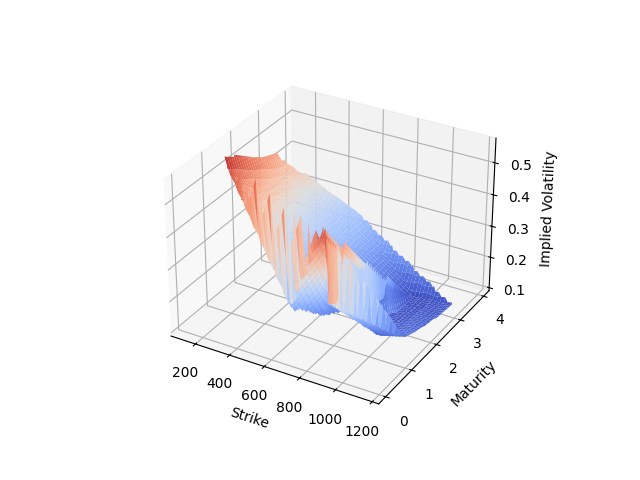

In [149]:
strikes_grid = np.linspace(options['strike'].min(), options['strike'].max(), 100)
maturities_grid = np.linspace(options['maturity'].min(), options['maturity'].max(), 100)
K_grid, T_grid = np.meshgrid(strikes_grid, maturities_grid)

#points = np.column_stack([calls['strike'].values, calls['maturity'].values])

vol_grid = griddata(
    points=(options['strike'], options['maturity']),
    values=options['implied_vol'],
    xi=(K_grid, T_grid),
    method='linear'
)

fig, ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot_surface(K_grid, T_grid, vol_grid, cmap=cm.coolwarm)
ax.set_xlabel('Strike')
ax.set_ylabel('Maturity')
ax.set_zlabel('Implied Volatility')

plt.show()